# Task2 实践 2：训练猫狗分类器

数据集：Kaggle Dogs vs. Cats（微软官方镜像，25000 张，猫狗各半）

## 第 1 步：统计猫狗数量 + 随机看图

In [5]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_manager.fontManager.addfont("/mnt/c/Windows/Fonts/msyh.ttc")
plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False
DATA_DIR = os.path.expanduser("~/datasets/PetImages")
BAD_FILES = {"Cat/666.jpg", "Dog/11702.jpg"}
def list_images(sub):
    files = []
    for f in sorted(os.listdir(os.path.join(DATA_DIR, sub))):
        if not f.lower().endswith(".jpg"):
            continue
        if f"{sub}/{f}" in BAD_FILES:
            continue
        files.append(os.path.join(DATA_DIR, sub, f))
    return files
cat_files = list_images("Cat")
dog_files = list_images("Dog")
print(f"猫: {len(cat_files)} 张")
print(f"狗: {len(dog_files)} 张")
print(f"总计: {len(cat_files) + len(dog_files)} 张")


猫: 12499 张
狗: 12499 张
总计: 24998 张


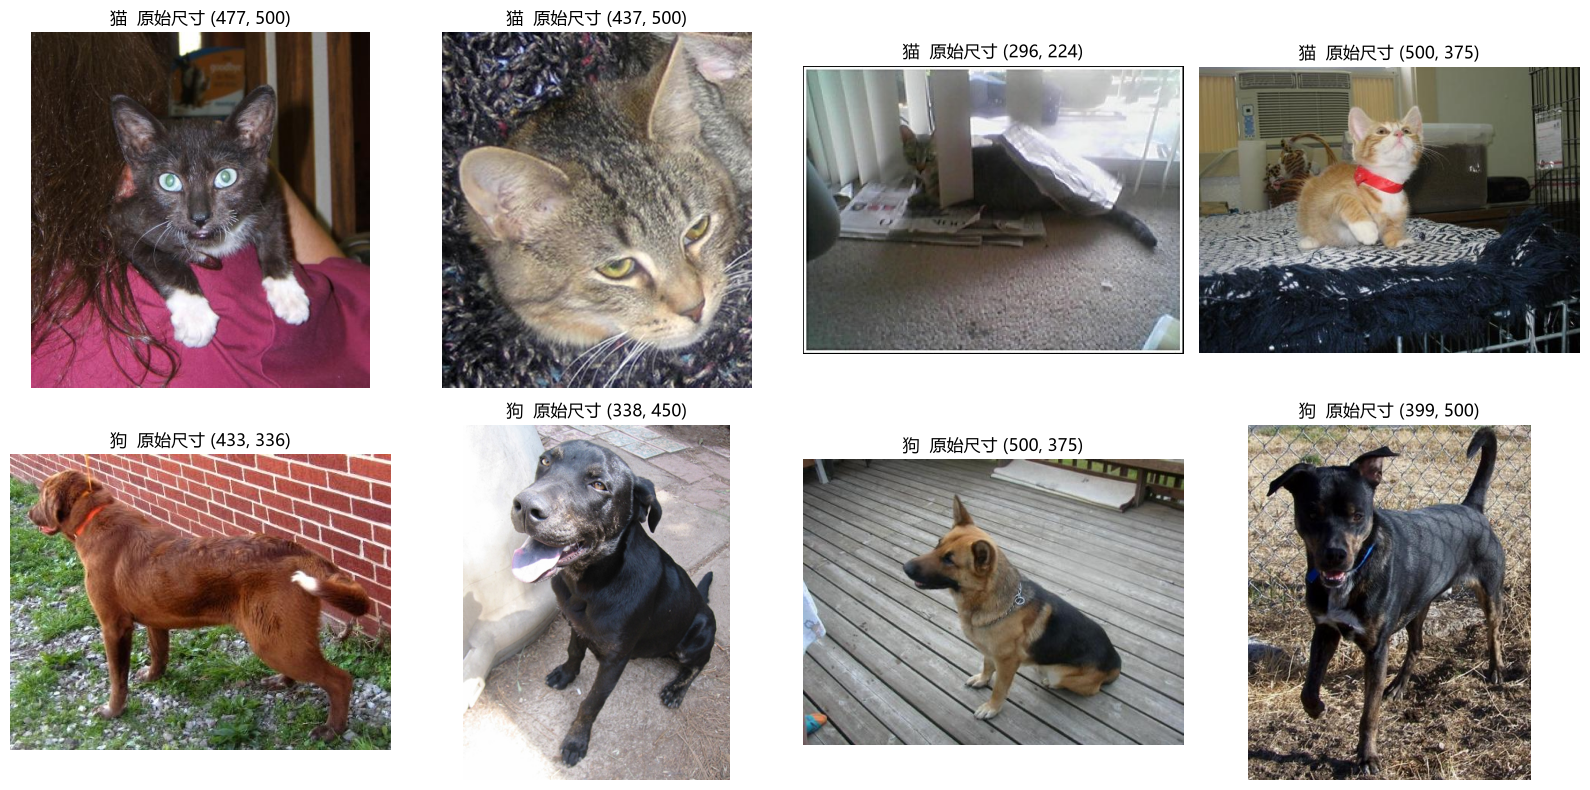

宽: 最小 42 / 平均 398 / 最大 500
高: 最小 36 / 平均 364 / 最大 500


In [6]:
random.seed(42)
show_cats = random.sample(cat_files, 4)
show_dogs = random.sample(dog_files, 4)
samples = [(p, 0) for p in show_cats] + [(p, 1) for p in show_dogs]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (path, label) in zip(axes.flat, samples):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"{'猫' if label == 0 else '狗'}  原始尺寸 {img.size}")
    ax.axis("off")
plt.tight_layout()
plt.show()
sizes = []
for p in random.sample(cat_files + dog_files, 500):
    with Image.open(p) as im:
        sizes.append(im.size)
w = np.array([s[0] for s in sizes])
h = np.array([s[1] for s in sizes])
print(f"宽: 最小 {w.min()} / 平均 {w.mean():.0f} / 最大 {w.max()}")
print(f"高: 最小 {h.min()} / 平均 {h.mean():.0f} / 最大 {h.max()}")


## 第 2 步：数据读取与预处理流程

预处理的五件事：统一尺寸（128x128）→ 统一 RGB → 转 Tensor（0~1）→ 归一化 → 打乱组 batch。
标签直接来自文件夹名：Cat=0，Dog=1。

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
IMG_SIZE = 128
basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.240, 0.225]),
])
class CatsDogsDataset(Dataset):
    """告诉 PyTorch：一共有多少张图、每张图怎么取"""
    def __init__(self, files, labels, transform=None):
        self.files = files
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]
print("Dataset 类定义完成")


Dataset 类定义完成


In [8]:
all_files = cat_files + dog_files
all_labels = [0] * len(cat_files) + [1] * len(dog_files)
random.seed(42)
idx = list(range(len(all_files)))
random.shuffle(idx)
all_files = [all_files[i] for i in idx]
all_labels = [all_labels[i] for i in idx]
n = len(all_files)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train_files, train_labels = all_files[:n_train], all_labels[:n_train]
val_files, val_labels = all_files[n_train:n_train+n_val], all_labels[n_train:n_train+n_val]
test_files, test_labels = all_files[n_train+n_val:], all_labels[n_train+n_val:]
print(f"train: {len(train_files)} | val: {len(val_files)} | test: {len(test_files)}")
train_ds = CatsDogsDataset(train_files, train_labels, basic_tf)
val_ds = CatsDogsDataset(val_files, val_labels, basic_tf)
test_ds = CatsDogsDataset(test_files, test_labels, basic_tf)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
print("DataLoader 准备完成")


train: 19998 | val: 2499 | test: 2501
DataLoader 准备完成


一个 batch 的图片张量: torch.Size([32, 3, 128, 128]) （32张图, 3通道, 128x128）
对应标签形状: torch.Size([32]) | 前 8 个标签: [0, 1, 1, 0, 0, 0, 0, 0]


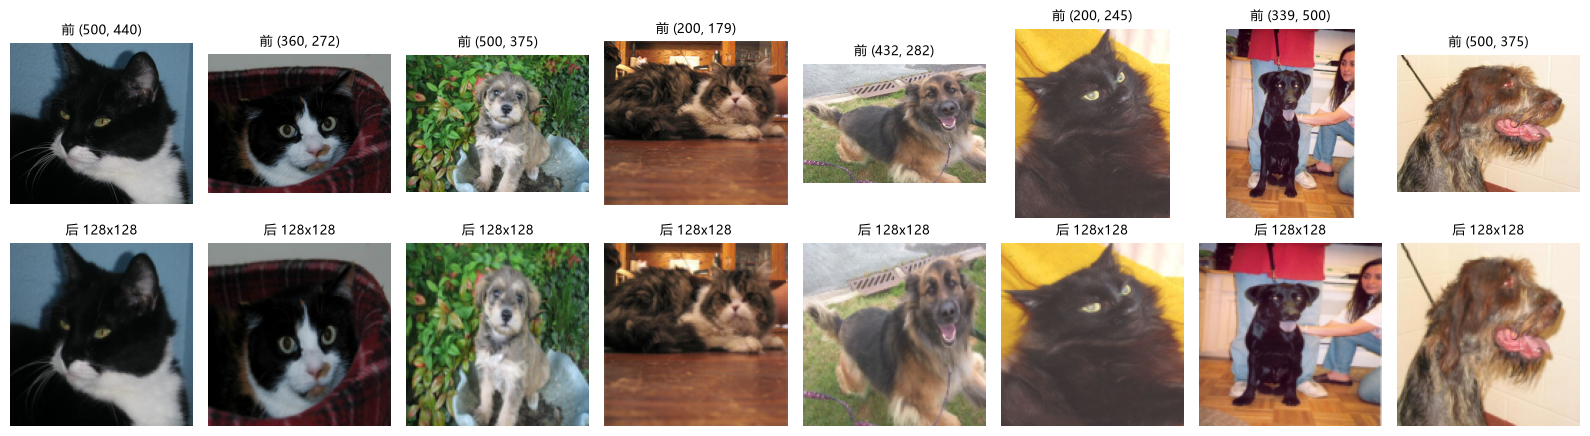

In [9]:
xb, yb = next(iter(train_loader))
print("一个 batch 的图片张量:", xb.shape, "（32张图, 3通道, 128x128）")
print("对应标签形状:", yb.shape, "| 前 8 个标签:", yb[:8].tolist())
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.240, 0.225]).view(3, 1, 1)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i in range(8):
    orig = Image.open(train_files[i]).convert("RGB")
    axes[0, i].imshow(orig)
    axes[0, i].set_title(f"前 {orig.size}", fontsize=9)
    axes[0, i].axis("off")
    t = basic_tf(orig) * std + mean
    axes[1, i].imshow(torch.clamp(t, 0, 1).permute(1, 2, 0))
    axes[1, i].set_title(f"后 {IMG_SIZE}x{IMG_SIZE}", fontsize=9)
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## 第 3 步：搭建 CNN

三个卷积块（Conv2d + ReLU + MaxPool）提取图像特征，最后两层 Linear 做分类。
输出是一个 logit，配 BCEWithLogitsLoss（和 Task1 同款）。

In [10]:
import torch.nn as nn
class CatsDogsCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CatsDogsCNN().to(device)
print(model)
print("设备:", device)
n_params = sum(p.numel() for p in model.parameters())
print(f"参数总量: {n_params:,}")


CatsDogsCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
设备: cuda
参数总量: 2,120,993


## 第 4 步：记录一张图经过每层的形状变化

拿刚才那个 batch 的前 4 张图，让它们逐层穿过网络，打印每层之后的形状。
观察规律：宽高每次被 MaxPool 减半，通道数越越深越多，最后 Flatten 摊平成一行数字。

In [11]:
with torch.no_grad():
    x = xb[:4].to(device)
    print("输入:", tuple(x.shape))
    for layer in model.features:
        x = layer(x)
        print(f"  {layer.__class__.__name__:<10} -> {tuple(x.shape)}")
    for layer in model.classifier:
        x = layer(x)
        print(f"  {layer.__class__.__name__:<10} -> {tuple(x.shape)}")


输入: (4, 3, 128, 128)
  Conv2d     -> (4, 16, 128, 128)
  ReLU       -> (4, 16, 128, 128)
  MaxPool2d  -> (4, 16, 64, 64)
  Conv2d     -> (4, 32, 64, 64)
  ReLU       -> (4, 32, 64, 64)
  MaxPool2d  -> (4, 32, 32, 32)
  Conv2d     -> (4, 64, 32, 32)
  ReLU       -> (4, 64, 32, 32)
  MaxPool2d  -> (4, 64, 16, 16)
  Flatten    -> (4, 16384)
  Linear     -> (4, 128)
  ReLU       -> (4, 128)
  Linear     -> (4, 1)


## 第 5 步：卷积输出的特征图可视化

把一张图喂进网络，看第一层和第三层卷积各自输出的 16 个通道。
亮度 = 激活强度：越白的地方说明该通道的卷积核在那里"看到了它要找的东西"。

这张图是: 猫


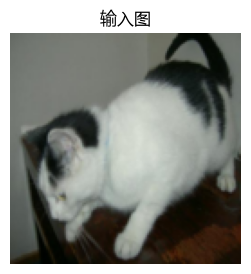

第一层卷积输出: (1, 16, 128, 128)
第三层卷积输出: (1, 64, 32, 32)


In [12]:
img0 = xb[0:1].to(device)
label0 = yb[0].item()
print("这张图是:", "狗" if label0 == 1 else "猫")
show_img = xb[0] * std + mean
plt.figure(figsize=(3, 3))
plt.imshow(torch.clamp(show_img, 0, 1).permute(1, 2, 0))
plt.title("输入图")
plt.axis("off")
plt.show()
with torch.no_grad():
    first_conv_out = model.features[0](img0)
    last_conv_out = model.features[6](model.features[:6](img0))
print("第一层卷积输出:", tuple(first_conv_out.shape))
print("第三层卷积输出:", tuple(last_conv_out.shape))


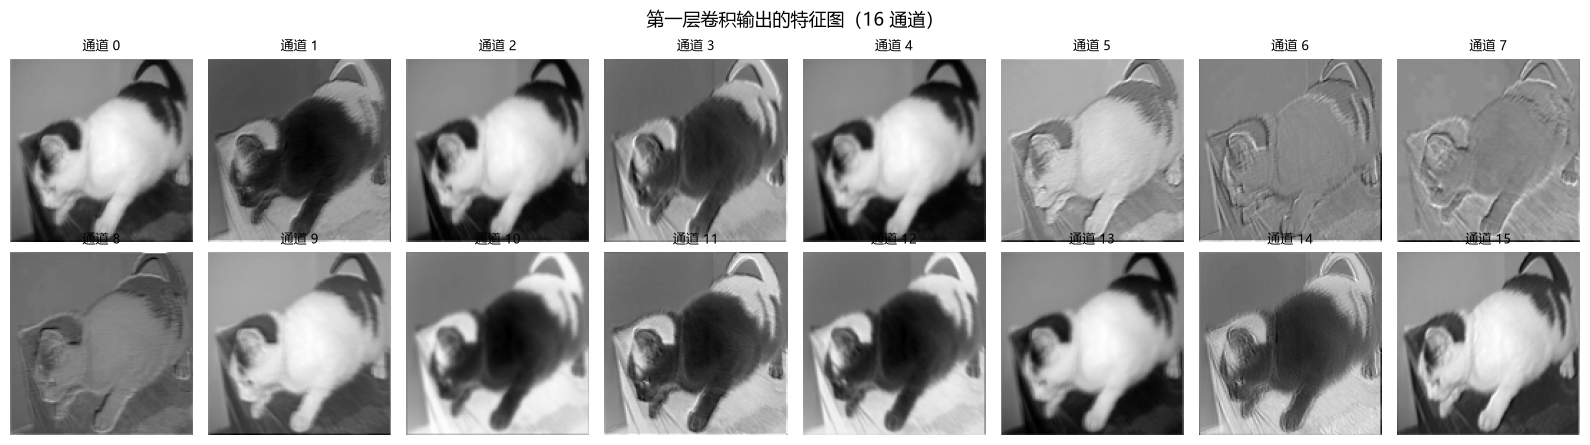

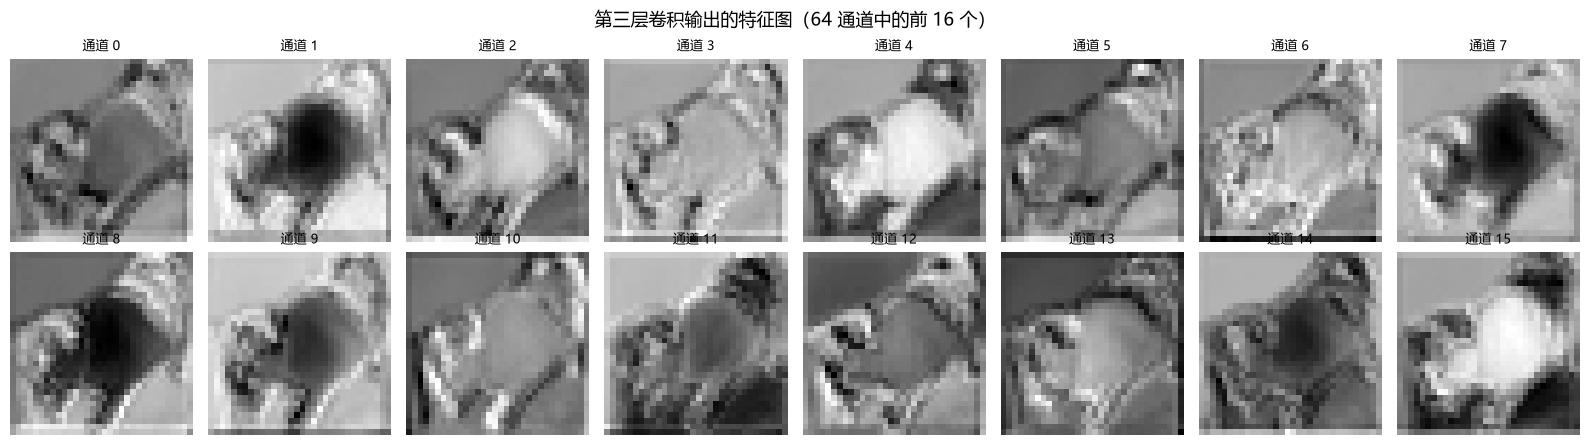

In [13]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(first_conv_out[0, i].cpu(), cmap="gray")
    ax.set_title(f"通道 {i}", fontsize=9)
    ax.axis("off")
fig.suptitle("第一层卷积输出的特征图（16 通道）", fontsize=13)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(last_conv_out[0, i].cpu(), cmap="gray")
    ax.set_title(f"通道 {i}", fontsize=9)
    ax.axis("off")
fig.suptitle("第三层卷积输出的特征图（64 通道中的前 16 个）", fontsize=13)
plt.tight_layout()
plt.show()


## 第 6 步：数据增强对照实验

数据增强 = 用随机变换"凭空制造"训练样本的新版本（翻转、旋转、变色……），
等于让模型每轮看到的同一张图都不太一样，逼它学"猫的本质"而不是"这张猫照片的摆法"。
**增强只加在训练集上，val/test 不加**（趁热打铁第 6 题的素材）。

先定义增强流水线，并把同一张图增强 8 次看看效果。

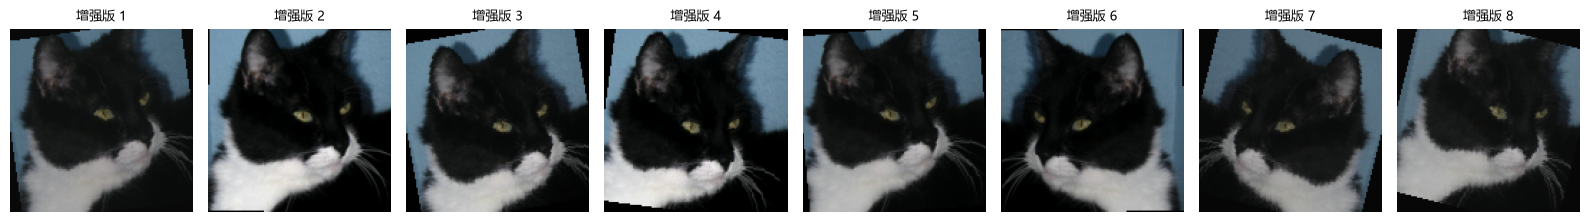

In [14]:
aug_tf = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.240, 0.225]),
])
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i in range(8):
    t = aug_tf(Image.open(train_files[0]).convert("RGB")) * std + mean
    axes[i].imshow(torch.clamp(t, 0, 1).permute(1, 2, 0))
    axes[i].set_title(f"增强版 {i+1}", fontsize=9)
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## 训练函数：照搬 Task1 的三火枪手，搬到 GPU 上

Task1 怎么训的这里就怎么训：zero_grad → backward → step，每轮结束在 val 上测。
唯一区别：数据要 .to(device) 搬到显卡，标签要变成 float 的列向量（BCE 的要求）。

In [15]:
criterion = nn.BCEWithLogitsLoss()
def train_model(model, train_loader, val_loader, epochs=12, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).float().view(-1, 1)
            logit = model(xb)
            loss = criterion(logit, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)
        model.eval()
        correct, val_sum, val_running = 0, 0, 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).float().view(-1, 1)
                logit = model(xb)
                val_running += criterion(logit, yb).item() * xb.size(0)
                correct += ((logit > 0).float() == yb).sum().item()
                val_sum += xb.size(0)
        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_running / val_sum)
        hist["val_acc"].append(correct / val_sum)
        print(f"Epoch {epoch:3d} | train_loss {train_loss:.4f} | "
              f"val_loss {hist['val_loss'][-1]:.4f} | val_acc {correct/val_sum:.4f}")
    return hist
print("训练函数定义完成")


训练函数定义完成


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   1 | train_loss 0.5962 | val_loss 0.4949 | val_acc 0.7571


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   2 | train_loss 0.4661 | val_loss 0.4505 | val_acc 0.7883


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   3 | train_loss 0.3878 | val_loss 0.4255 | val_acc 0.8063


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   4 | train_loss 0.3215 | val_loss 0.3850 | val_acc 0.8363
Epoch   5 | train_loss 0.2428 | val_loss 0.4422 | val_acc 0.8283
Epoch   6 | train_loss 0.1572 | val_loss 0.5433 | val_acc 0.8211
Epoch   7 | train_loss 0.0923 | val_loss 0.5915 | val_acc 0.8175
Epoch   8 | train_loss 0.0537 | val_loss 0.7992 | val_acc 0.8227
Epoch   9 | train_loss 0.0366 | val_loss 1.0119 | val_acc 0.7959
Epoch  10 | train_loss 0.0376 | val_loss 0.9209 | val_acc 0.8147
Epoch  11 | train_loss 0.0316 | val_loss 1.1753 | val_acc 0.8091
Epoch  12 | train_loss 0.0289 | val_loss 1.2651 | val_acc 0.8175
总用时: 242 秒


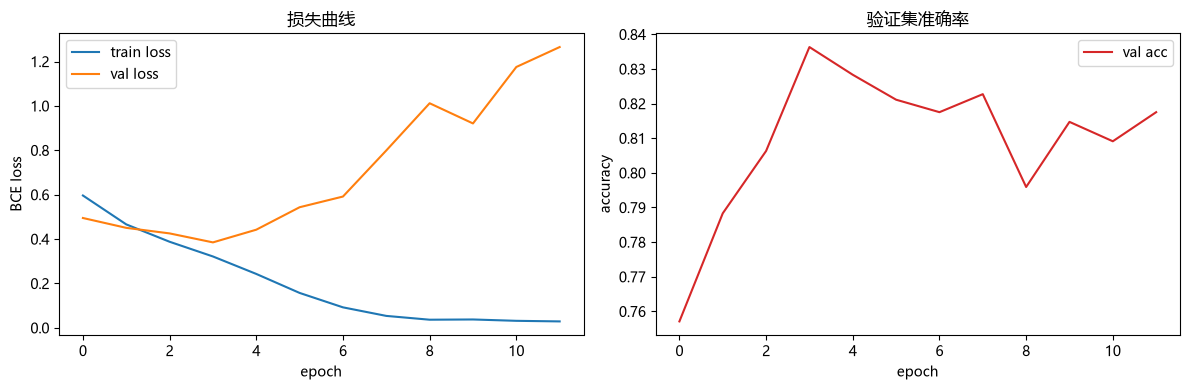

In [16]:
train_loader_fast = DataLoader(train_ds, batch_size=32, shuffle=True,
                               num_workers=4, pin_memory=True, persistent_workers=True)
val_loader_fast = DataLoader(val_ds, batch_size=64, shuffle=False,
                             num_workers=4, pin_memory=True, persistent_workers=True)
import time
t0 = time.time()
model_base = CatsDogsCNN()
hist_base = train_model(model_base, train_loader_fast, val_loader_fast, epochs=12)
print(f"总用时: {time.time()-t0:.0f} 秒")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_base["train_loss"], label="train loss")
axes[0].plot(hist_base["val_loss"], label="val loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss"); axes[0].legend(); axes[0].set_title("损失曲线")
axes[1].plot(hist_base["val_acc"], label="val acc", color="tab:red")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("验证集准确率")
plt.tight_layout()
plt.show()


## 对照实验：增强版训练

基线模型已经出现了典型过拟合（train_loss 降到 0.03，val_loss 反而从 0.39 涨到 1.27）。
现在用**一模一样的网络、一模一样的轮数**，只把训练集换成增强版，看效果差多少。
val/test 保持不增强（评测必须用"原始长相"的图）。

In [17]:
train_ds_aug = CatsDogsDataset(train_files, train_labels, aug_tf)
train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
import time
t0 = time.time()
model_aug = CatsDogsCNN()
hist_aug = train_model(model_aug, train_loader_aug, val_loader_fast, epochs=12)
print(f"总用时: {time.time()-t0:.0f} 秒")


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   1 | train_loss 0.6005 | val_loss 0.4945 | val_acc 0.7587


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   2 | train_loss 0.5012 | val_loss 0.4637 | val_acc 0.7915


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   3 | train_loss 0.4496 | val_loss 0.4023 | val_acc 0.8231
Epoch   4 | train_loss 0.4130 | val_loss 0.4023 | val_acc 0.8123


/home/yeji/ml-env/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch   5 | train_loss 0.3867 | val_loss 0.3501 | val_acc 0.8427
Epoch   6 | train_loss 0.3629 | val_loss 0.3253 | val_acc 0.8635
Epoch   7 | train_loss 0.3422 | val_loss 0.3112 | val_acc 0.8723
Epoch   8 | train_loss 0.3228 | val_loss 0.3056 | val_acc 0.8768
Epoch   9 | train_loss 0.3082 | val_loss 0.2866 | val_acc 0.8788
Epoch  10 | train_loss 0.2939 | val_loss 0.2733 | val_acc 0.8888
Epoch  11 | train_loss 0.2744 | val_loss 0.2643 | val_acc 0.8952
Epoch  12 | train_loss 0.2684 | val_loss 0.2591 | val_acc 0.8924
总用时: 283 秒


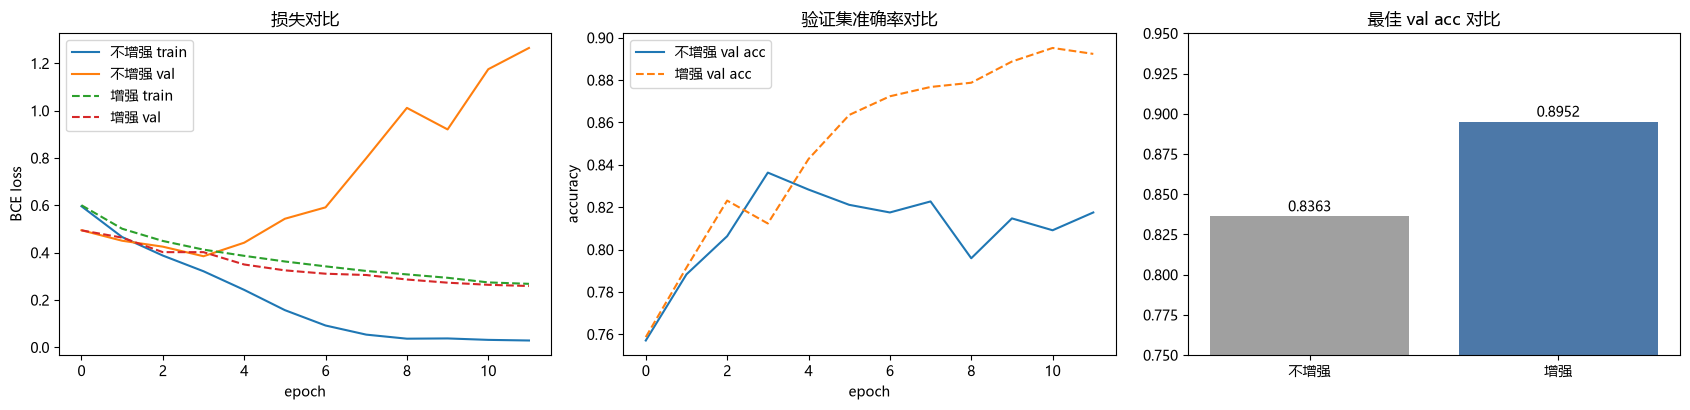

不增强 最佳 val acc: 0.8363
增强后 最佳 val acc: 0.8952


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
axes[0].plot(hist_base["train_loss"], label="不增强 train")
axes[0].plot(hist_base["val_loss"], label="不增强 val")
axes[0].plot(hist_aug["train_loss"], "--", label="增强 train")
axes[0].plot(hist_aug["val_loss"], "--", label="增强 val")
axes[0].set_title("损失对比"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss"); axes[0].legend()
axes[1].plot(hist_base["val_acc"], label="不增强 val acc")
axes[1].plot(hist_aug["val_acc"], "--", label="增强 val acc")
axes[1].set_title("验证集准确率对比"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
best_base = max(hist_base["val_acc"])
best_aug = max(hist_aug["val_acc"])
axes[2].bar(["不增强", "增强"], [best_base, best_aug], color=["#A0A0A0", "#4C78A8"])
axes[2].set_ylim(0.75, 0.95)
for i, v in enumerate([best_base, best_aug]):
    axes[2].text(i, v + 0.003, f"{v:.4f}", ha="center")
axes[2].set_title("最佳 val acc 对比")
plt.tight_layout()
plt.show()
print(f"不增强 最佳 val acc: {best_base:.4f}")
print(f"增强后 最佳 val acc: {best_aug:.4f}")


## 第 7 步：混淆矩阵 + 看预测错误的样本

用增强版模型（表现更好的那个）在 test 集上做最终评测——test 只用这一次。
混淆矩阵：对角线是判对的，圈外两格分别是"把猫判成狗"和"把狗判成猫"。

test acc: 0.8920


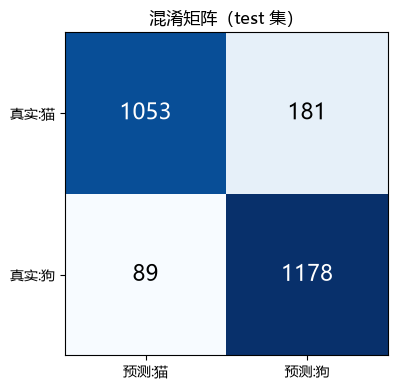

In [19]:
from sklearn.metrics import confusion_matrix
model_aug.eval()
all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logit = model_aug(xb.to(device))
        prob = torch.sigmoid(logit).cpu().view(-1)
        all_probs.extend(prob.tolist())
        all_preds.extend((prob > 0.5).tolist())
        all_targets.extend(yb.tolist())
test_acc = sum(p == t for p, t in zip(all_preds, all_targets)) / len(all_targets)
print(f"test acc: {test_acc:.4f}")
cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["预测:猫", "预测:狗"])
ax.set_yticks([0, 1], ["真实:猫", "真实:狗"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("混淆矩阵（test 集）")
plt.tight_layout()
plt.show()


## 看看它错在哪些图上

把判错的图抽出来（最多 8 张），标题写明"真是什么、判成了什么"。
观察：错例往往有什么共同点？（遮挡 / 姿态奇怪 / 主体太小 / 猫狗长得像……）

判错 270 / 2501 张


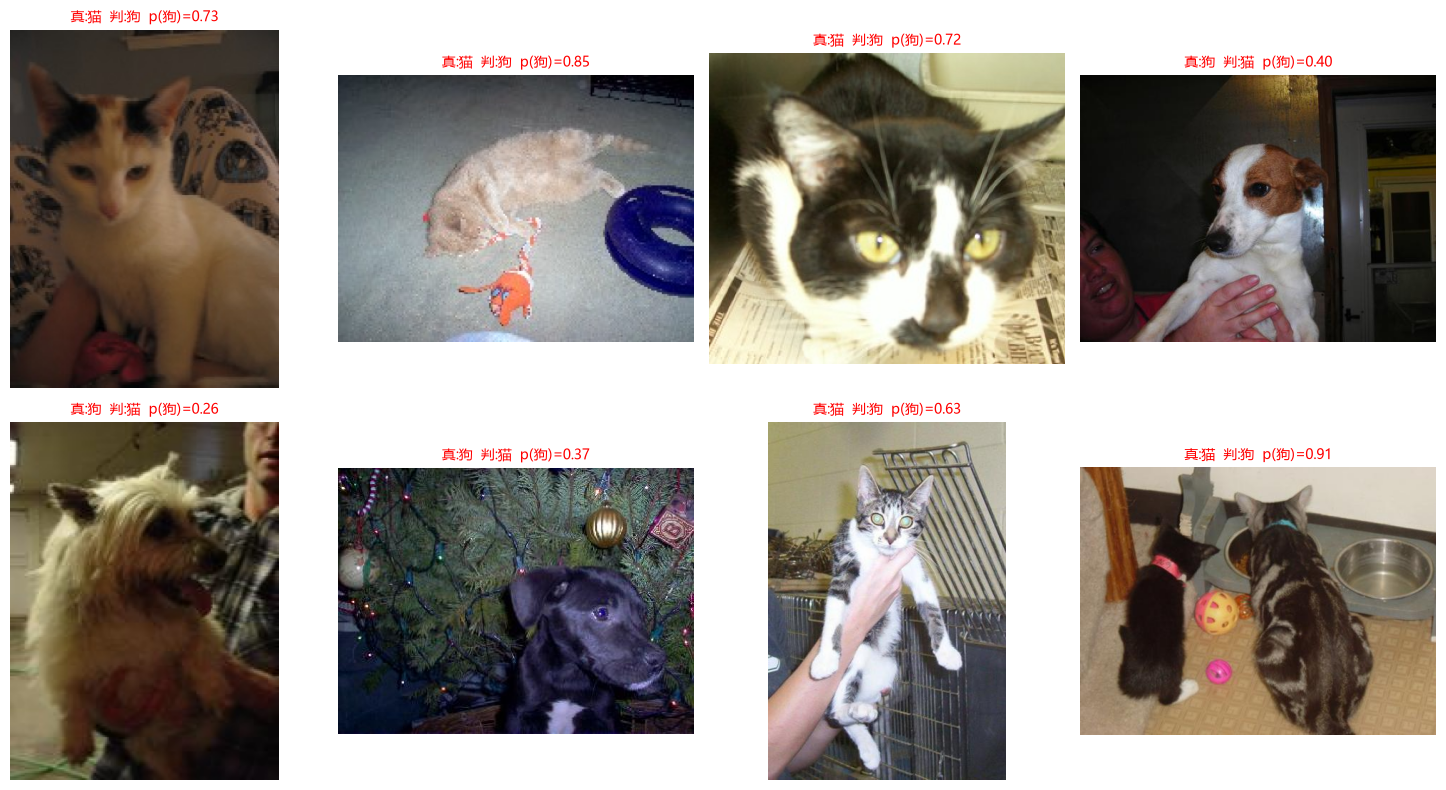

In [20]:
wrong_idx = [i for i, (p, t) in enumerate(zip(all_preds, all_targets)) if p != t]
print(f"判错 {len(wrong_idx)} / {len(all_targets)} 张")
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, i in zip(axes.flat, wrong_idx[:8]):
    img = Image.open(test_files[i]).convert("RGB")
    ax.imshow(img)
    true = "猫" if all_targets[i] == 0 else "狗"
    pred = "猫" if all_preds[i] == 0 else "狗"
    ax.set_title(f"真:{true}  判:{pred}  p(狗)={all_probs[i]:.2f}", color="red", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 第 8 步：保存最好的模型 + 加载复现

增强版表现更好，保存它的 state_dict（和 Task1 同款做法：只存参数字典，不存整个模型）。
保存后新建一个空白模型加载权重，在 test 集上重新评测——分数应该一分不差。

In [21]:
torch.save(model_aug.state_dict(), "cats_dogs_cnn.pth")
import os
print("已保存 cats_dogs_cnn.pth,", os.path.getsize("cats_dogs_cnn.pth"), "字节")
model_loaded = CatsDogsCNN().to(device)
model_loaded.load_state_dict(torch.load("cats_dogs_cnn.pth", map_location=device))
model_loaded.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        pred = (model_loaded(xb.to(device)).view(-1) > 0).long().cpu()
        correct += (pred == yb).sum().item()
        total += len(yb)
print(f"加载后模型 test acc: {correct/total:.4f}（应与上面 0.8920 一分不差）")


已保存 cats_dogs_cnn.pth, 8488613 字节
加载后模型 test acc: 0.8920（应与上面 0.8920 一分不差）


## 第 9 步：画出模型结构图

按数据流动顺序画出每一层：蓝色 = 卷积，灰色 = 池化，绿色 = 全连接。
看颜色就知道规律：宽高逐层减半、通道逐层翻倍。图同时存成 architecture-diagram.png。

findfont: Failed to find font weight bold for Microsoft YaHei, now using 400.


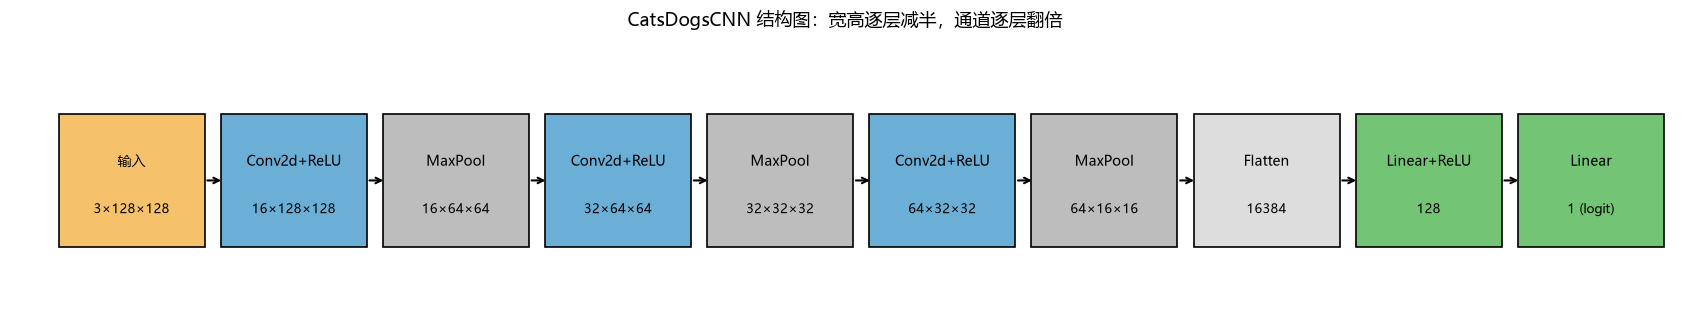

结构图已保存为 architecture-diagram.png


In [22]:
steps = [
    ("输入",          "3×128×128",  "#F5C26B"),
    ("Conv2d+ReLU",  "16×128×128", "#6BAED6"),
    ("MaxPool",      "16×64×64",   "#BDBDBD"),
    ("Conv2d+ReLU",  "32×64×64",   "#6BAED6"),
    ("MaxPool",      "32×32×32",   "#BDBDBD"),
    ("Conv2d+ReLU",  "64×32×32",   "#6BAED6"),
    ("MaxPool",      "64×16×16",   "#BDBDBD"),
    ("Flatten",      "16384",      "#DDDDDD"),
    ("Linear+ReLU",  "128",        "#74C476"),
    ("Linear",       "1 (logit)",  "#74C476"),
]
fig, ax = plt.subplots(figsize=(17, 3.2))
for i, (name, shape, color) in enumerate(steps):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, facecolor=color, edgecolor="black", linewidth=1.2))
    ax.text(i + 0.45, 0.64, name, ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(i + 0.45, 0.28, shape, ha="center", va="center", fontsize=9)
    if i < len(steps) - 1:
        ax.annotate("", xy=(i + 1.02, 0.5), xytext=(i + 0.9, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_xlim(-0.3, len(steps))
ax.set_ylim(-0.4, 1.6)
ax.axis("off")
ax.set_title("CatsDogsCNN 结构图：宽高逐层减半，通道逐层翻倍", fontsize=13)
plt.tight_layout()
plt.savefig("architecture-diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("结构图已保存为 architecture-diagram.png")
